In [13]:
#Instalacja bibliotek w Jupyter
!pip install numpy
!pip install matplotlib
!pip install ipywidgets
!pip install ipywidgets jupyterlab_widgets

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [1]:
#Inicjalizacja bibliotek
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from ipywidgets import interact, IntSlider

## Preprocessing obrazu

(np.float64(-0.5), np.float64(399.5), np.float64(399.5), np.float64(-0.5))

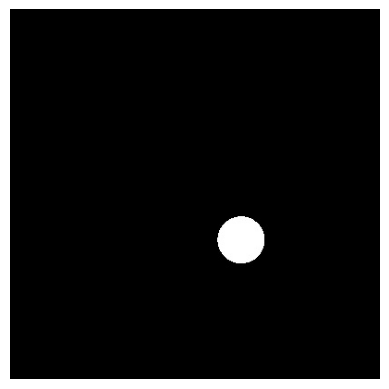

In [16]:
#Wczytanie obrazu
img = Image.open("./obraz/Kropka.jpg")
plt.imshow(img)
plt.axis("off")

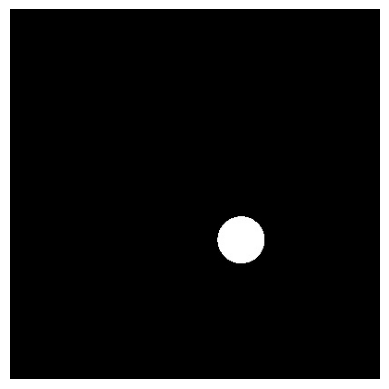

In [17]:
#Zamiana w skalę szarości i zamiana w array
gray = img.convert("L")
plt.imshow(gray, cmap="gray")
plt.axis("off")

arr = np.array(gray).astype(np.float64)

## Transformata Radona

In [18]:
from ipywidgets import interact, IntSlider
import matplotlib.pyplot as plt
from IPython.display import display
import ipywidgets as widgets
import numpy as np

emiters_number = 100
l = 200
delta_alpha = 1

def bresenham_line(x0, y0, x1, y1):
    points = []
    x0, y0, x1, y1 = int(round(x0)), int(round(y0)), int(round(x1)), int(round(y1))
    dx = abs(x1 - x0); dy = abs(y1 - y0)
    sx = 1 if x0 < x1 else -1
    sy = 1 if y0 < y1 else -1
    err = dx - dy
    while True:
        points.append((x0, y0))
        if x0 == x1 and y0 == y1:
            break
        e2 = 2 * err
        if e2 > -dy: err -= dy; x0 += sx
        if e2 <  dx: err += dx; y0 += sy
    return points

def radon_transform(arr, emiters_number, delta_alpha, l=None):
    height, width = arr.shape
    cx = width // 2; cy = height // 2
    if l is None:
        l = int(np.sqrt(width**2 + height**2))
    angles = np.deg2rad(np.arange(0, 180, delta_alpha))
    emiters = np.linspace(-l/2, l/2, emiters_number)
    sinogram = []
    for theta in angles:
        dx = np.cos(theta); dy = np.sin(theta)
        px = -dy;           py = dx
        row = []
        for t in emiters:
            x0 = cx + t * px; y0 = cy + t * py
            x1 = x0 + dx * l; y1 = y0 + dy * l
            points = bresenham_line(x0, y0, x1, y1)
            s = sum(arr[y, x] for x, y in points if 0 <= x < width and 0 <= y < height)
            row.append(s)
        sinogram.append(row)
    return np.array(sinogram)

def backproject(sinogram, delta_alpha, output_size):
    height = width = output_size
    cx = width // 2; cy = height // 2
    reconstruction = np.zeros((height, width), dtype=np.float64)
    angles = np.deg2rad(np.arange(0, 180, delta_alpha))
    n_detectors = sinogram.shape[1]
    emiters = np.linspace(-output_size/2, output_size/2, n_detectors)

    ys, xs = np.mgrid[0:height, 0:width]
    xs = xs - cx; ys = ys - cy

    for i, theta in enumerate(angles):
        dx = np.cos(theta); dy = np.sin(theta)
        px = -dy;           py = dx
        t = xs * px + ys * py
        indices = np.interp(t, emiters, np.arange(n_detectors))
        i0 = np.clip(indices.astype(int), 0, n_detectors - 2)
        i1 = i0 + 1
        frac = indices - i0
        row = sinogram[i]
        vals = row[i0] * (1 - frac) + row[i1] * frac
        reconstruction += vals

    reconstruction -= reconstruction.min()
    if reconstruction.max() > 0:
        reconstruction /= reconstruction.max()
    return reconstruction

out_geom   = widgets.Output()
out_sino   = widgets.Output()
out_recon  = widgets.Output()

emiters_slider = widgets.IntSlider(min=10, max=300, step=10,  value=100, description="Emiters")
delta_slider   = widgets.IntSlider(min=1,  max=10,  step=1,   value=1,   description="dα")
theta_slider   = widgets.IntSlider(min=0,  max=179, step=1,   value=0,   description="θ")

run_button    = widgets.Button(description="Compute Sinogram",  button_style='success')
recon_button  = widgets.Button(description="Reconstruct Image", button_style='info')

sinogram_cache = [None]

def update_geometry(change=None):
    with out_geom:
        out_geom.clear_output(wait=True)
        en    = emiters_slider.value
        theta_deg = theta_slider.value
        theta = np.deg2rad(theta_deg)
        height, width = arr.shape
        cx = width // 2; cy = height // 2
        dx = np.cos(theta); dy = np.sin(theta)
        px = -dy;           py = dx
        l_geom = int(np.sqrt(width**2 + height**2))
        emiters = np.linspace(-l_geom/2, l_geom/2, en)
        fig, ax = plt.subplots(figsize=(5, 5))
        ax.imshow(arr, cmap='gray')
        ax.set_title(f"Geometry θ={theta_deg}°")
        for t in emiters:
            x0 = cx + t * px; y0 = cy + t * py
            ax.plot([x0 - dx*l_geom, x0 + dx*l_geom],
                    [y0 - dy*l_geom, y0 + dy*l_geom], linewidth=0.5)
        ax.axis('off')
        plt.show()

def on_run_clicked(b):
    with out_sino:
        out_sino.clear_output(wait=True)
        sino = radon_transform(arr,
                               emiters_number=emiters_slider.value,
                               delta_alpha=delta_slider.value)
        sinogram_cache[0] = sino
        fig, ax = plt.subplots(figsize=(6, 5))
        ax.imshow(sino, cmap='gray', aspect='auto')
        ax.set_title("Sinogram")
        ax.set_xlabel("Detectors"); ax.set_ylabel("Angle")
        plt.show()

def on_recon_clicked(b):
    with out_recon:
        out_recon.clear_output(wait=True)
        if sinogram_cache[0] is None:
            print("Najpierw oblicz sinogram przyciskiem 'Compute Sinogram'.")
            return
        recon = backproject(sinogram_cache[0],
                            delta_alpha=delta_slider.value,
                            output_size=max(arr.shape))
        fig, ax = plt.subplots(figsize=(6, 5))
        ax.imshow(recon, cmap='gray')
        ax.set_title("Rekonstrukcja (backprojection)")
        ax.axis('off')
        plt.show()

emiters_slider.observe(update_geometry, names='value')
theta_slider.observe(update_geometry,   names='value')
run_button.on_click(on_run_clicked)
recon_button.on_click(on_recon_clicked)

display(widgets.VBox([
    emiters_slider,
    delta_slider,
    theta_slider,
    widgets.HBox([run_button, recon_button]),
    out_geom,
    out_sino,
    out_recon,
]))

update_geometry()
